In [1]:
import requests
from bs4 import BeautifulSoup
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://www.imdb.com/chart/top/"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36"
}

In [3]:
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, "html.parser")


In [4]:
# Find the script tag containing JSON-LD data
json_ld_tag = soup.find("script", type="application/ld+json")
data = json.loads(json_ld_tag.string)


In [5]:
soup = BeautifulSoup(response.content, "html.parser")


In [6]:
top_movies = data["itemListElement"][:10]
top_movies

[{'@type': 'ListItem',
  'item': {'@type': 'Movie',
   'url': 'https://www.imdb.com/title/tt0111161/',
   'name': 'The Shawshank Redemption',
   'alternateName': 'Die Verurteilten',
   'description': 'A banker convicted of uxoricide forms a friendship over a quarter century with a hardened convict, while maintaining his innocence and trying to remain hopeful through simple compassion.',
   'image': 'https://m.media-amazon.com/images/M/MV5BMDAyY2FhYjctNDc5OS00MDNlLThiMGUtY2UxYWVkNGY2ZjljXkEyXkFqcGc@._V1_.jpg',
   'aggregateRating': {'@type': 'AggregateRating',
    'bestRating': 10,
    'worstRating': 1,
    'ratingValue': 9.3,
    'ratingCount': 3038400},
   'contentRating': '12',
   'genre': 'Drama',
   'duration': 'PT2H22M'}},
 {'@type': 'ListItem',
  'item': {'@type': 'Movie',
   'url': 'https://www.imdb.com/title/tt0068646/',
   'name': 'The Godfather',
   'alternateName': 'Der Pate',
   'description': 'The aging patriarch of an organized crime dynasty transfers control of his cland

In [7]:
for movie in top_movies:
    info = movie["item"]
    print(f"{info['name']} ({info['aggregateRating']['ratingValue']}/10)")

The Shawshank Redemption (9.3/10)
The Godfather (9.2/10)
The Dark Knight (9/10)
The Godfather Part II (9/10)
12 Angry Men (9/10)
The Lord of the Rings: The Return of the King (9/10)
Schindler&apos;s List (9/10)
Pulp Fiction (8.9/10)
The Lord of the Rings: The Fellowship of the Ring (8.9/10)
Il buono, il brutto, il cattivo (8.8/10)


In [8]:
# creating empty movie list 
movie_list = []
for movie in top_movies:
    item = movie["item"]
    movie_list.append({
        "Title": item["name"],
        "Rating": float(item["aggregateRating"]["ratingValue"])
    })

In [9]:
# Convert to DataFrame
df = pd.DataFrame(movie_list)




In [10]:
# Sort by rating
df = df.sort_values(by="Rating", ascending=True)
df

,Title,Rating
9,"Il buono, il brutto, il cattivo",8.8
7,Pulp Fiction,8.9
8,The Lord of the Rings: The Fellowship of the Ring,8.9
2,The Dark Knight,9.0
3,The Godfather Part II,9.0
4,12 Angry Men,9.0
5,The Lord of the Rings: The Return of the King,9.0
6,Schindler&apos;s List,9.0
1,The Godfather,9.2
0,The Shawshank Redemption,9.3


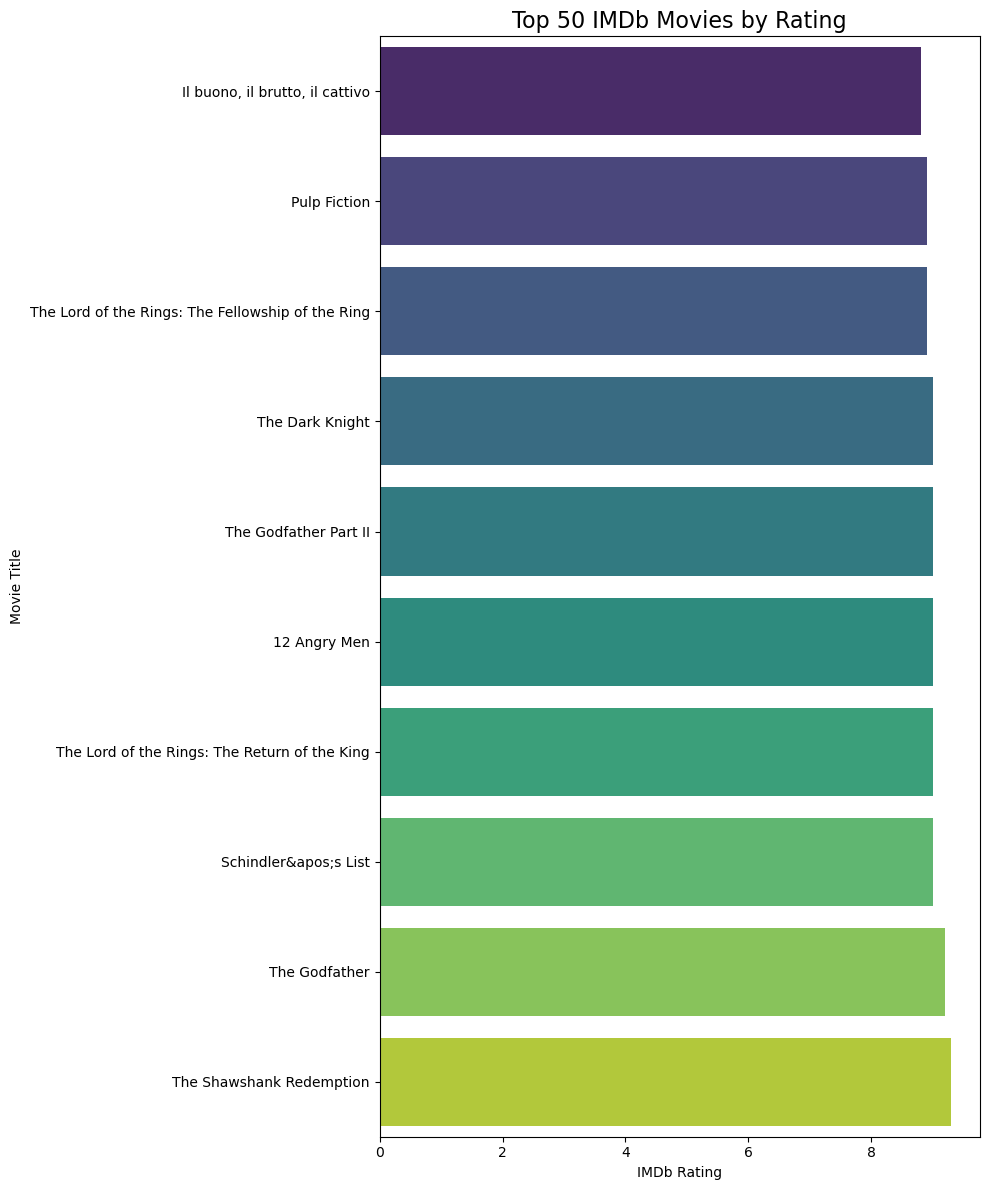

In [11]:
plt.figure(figsize=(10, 12))
sns.barplot(x="Rating", y="Title", hue="Title", data=df, palette="viridis", legend=False)
plt.title("Top 50 IMDb Movies by Rating", fontsize=16)
plt.xlabel("IMDb Rating")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()


In [12]:
df_top10 = df.sort_values(by="Rating", ascending=False).head(10)


<Axes: xlabel='Rating', ylabel='Title'>

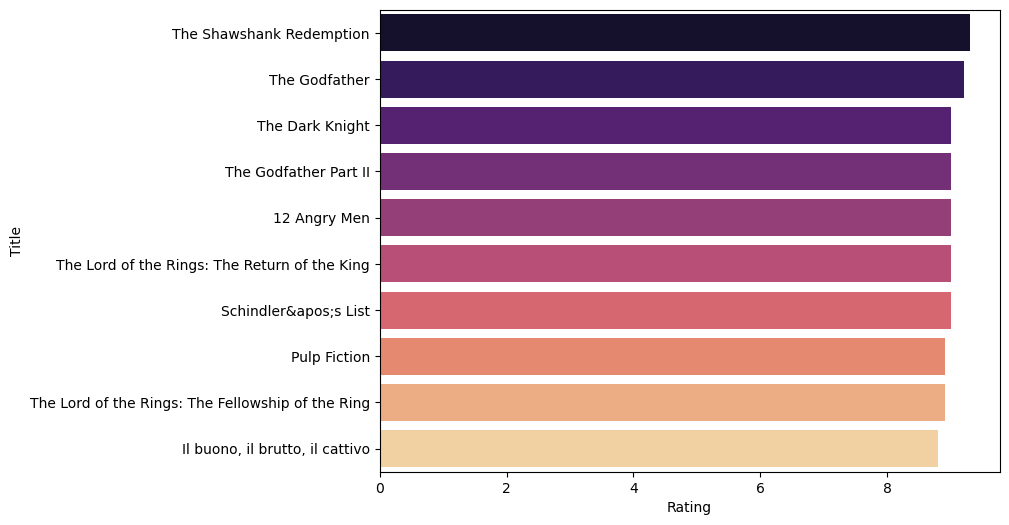

In [33]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Rating", y="Title", hue="Title", data=df_top10, palette="magma", legend=False)
